## Configuración Global

In [7]:
# ==========================================
# 1. CONFIGURACIÓN Y LIBRERÍAS
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import sqlite3
import os

# Configuración de visualización
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

# Reproducibilidad (Punto 5 de la rúbrica)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Rutas relativas (Evita rutas absolutas como C:/Users/...)
PATH_DB = os.path.join('data', 'data_accidentes.sqlite3')

## Carga y construcción del dataset

In [11]:
# ==========================================
# 2. CARGA Y CONSTRUCCIÓN DEL DATASET
# ==========================================

def construir_dataset_maestro(path_db):
    if not os.path.exists(path_db):
        raise FileNotFoundError(f"No se encontró la base de datos en: {path_db}")

    con = sqlite3.connect(path_db)
    # Carga con parseo de fechas para la ventana de tiempo (TW)
    accidentes = pd.read_sql('SELECT * FROM accidentes', con, parse_dates=['TW'])
    clima = pd.read_sql('SELECT * FROM clima', con, parse_dates=['TW'])
    con.close()
    
    # Estandarización de llaves
    accidentes['TW'] = accidentes['TW'].dt.floor('h')
    clima['TW'] = clima['TW'].dt.floor('h')
    accidentes['BARRIO'] = accidentes['BARRIO'].str.strip().str.upper()
    clima['BARRIO'] = clima['BARRIO'].str.strip().str.upper()
    
    # Identificar combinaciones únicas donde SÍ hubo accidentes (Positivos)
    positivos = accidentes[['TW', 'BARRIO']].drop_duplicates()
    positivos['target'] = 1
    
    # El universo es 'clima' (contiene todas las horas/barrios). 
    # Left join para marcar con 1 los accidentes y con 0 el resto.
    df = pd.merge(clima, positivos, on=['TW', 'BARRIO'], how='left')
    df['target'] = df['target'].fillna(0).astype(int)
    
    print(f"Dataset construido con {len(df):,} registros.")
    print(f"Casos positivos: {df['target'].sum():,} ({df['target'].mean()*100:.2f}%)")
    
    return df

# Ejecución de la carga
df = construir_dataset_maestro(PATH_DB)

Dataset construido con 7,991,780 registros.
Casos positivos: 120,475 (1.51%)


## Análisis Exploratorio - Temporal y Espacial

/tmp/ipykernel_4273/2213698599.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=accidentes_pos, x='hora', ax=axes[0], palette='viridis')


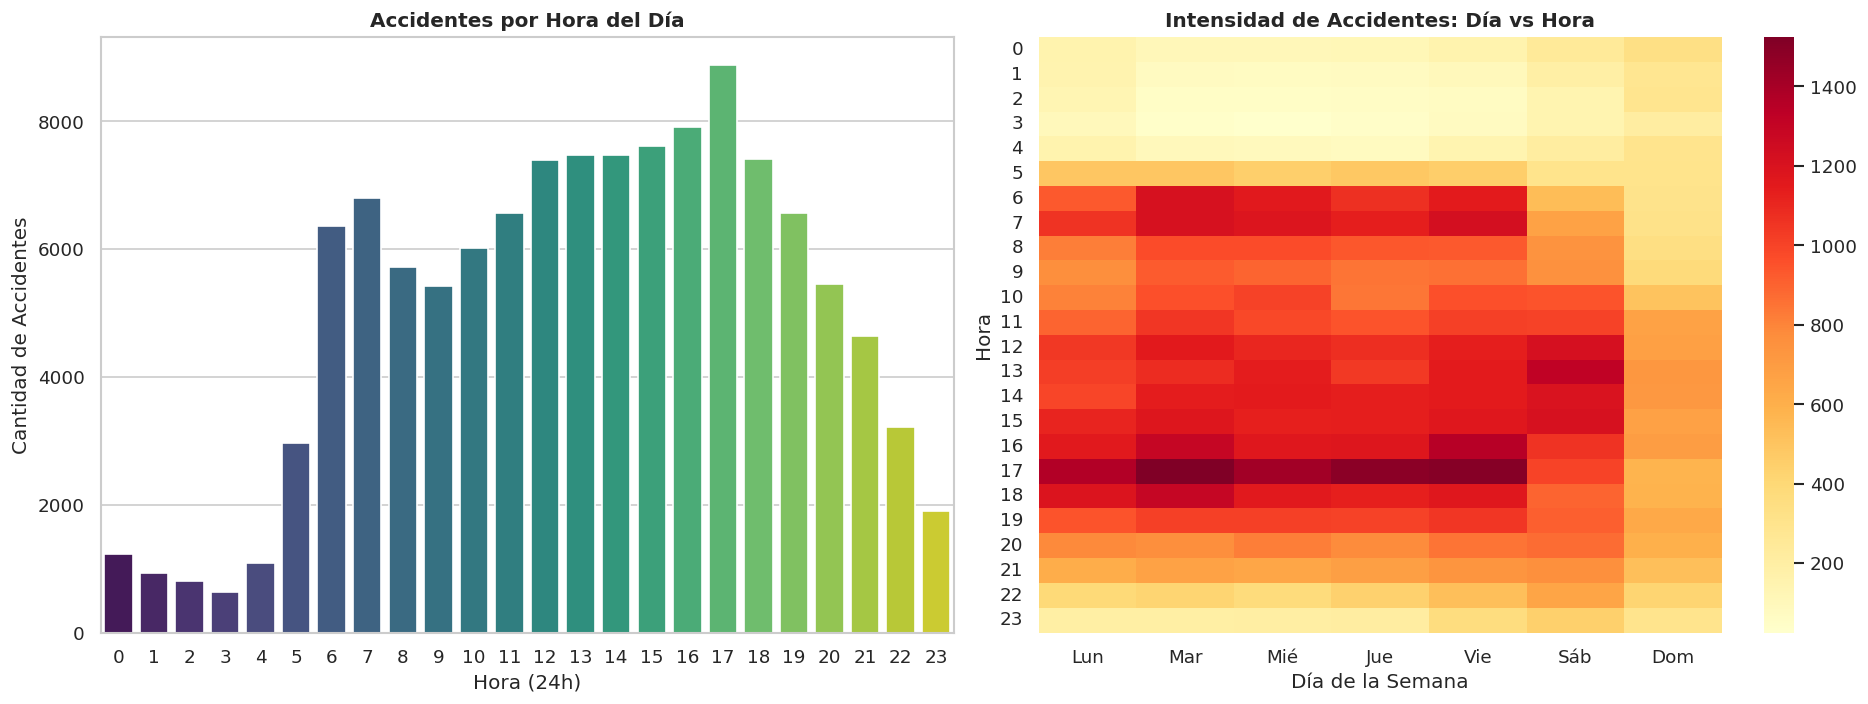

/tmp/ipykernel_4273/2213698599.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_tasa['tasa'], y=top_tasa.index, palette='magma')


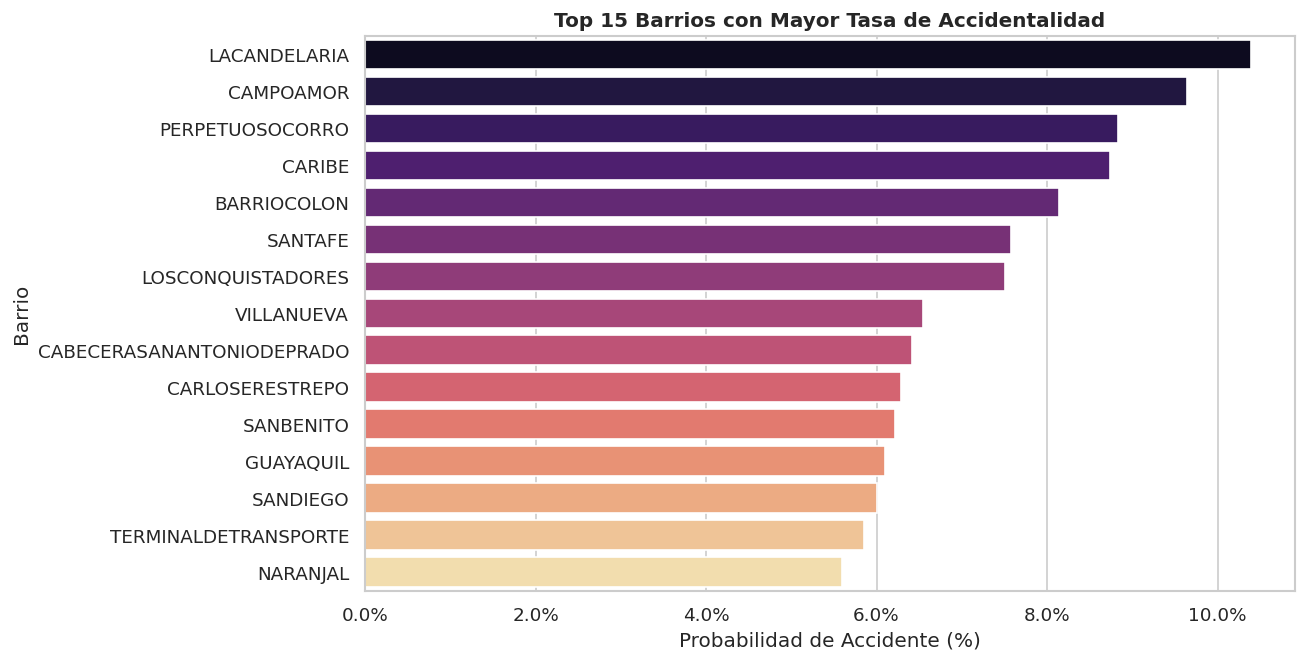

In [14]:
# ==========================================
# 3. EDA: ANÁLISIS TEMPORAL Y ESPACIAL
# ==========================================

# 3.1 Preparación de datos para visualización
accidentes_pos = df[df['target'] == 1].copy()
accidentes_pos['hora'] = accidentes_pos['TW'].dt.hour
accidentes_pos['dia_sem'] = accidentes_pos['TW'].dt.dayofweek # 0=Lunes, 6=Domingo

# --- Gráficos Temporales ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accidentes por Hora
sns.countplot(data=accidentes_pos, x='hora', ax=axes[0], palette='viridis')
axes[0].set_title('Accidentes por Hora del Día', fontweight='bold')
axes[0].set_xlabel('Hora (24h)')
axes[0].set_ylabel('Cantidad de Accidentes')

# Heatmap Hora vs Día de la Semana
dias_es = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']
pivot_h_d = accidentes_pos.groupby(['hora', 'dia_sem'])['target'].count().unstack()
sns.heatmap(pivot_h_d, cmap='YlOrRd', ax=axes[1], xticklabels=dias_es)
axes[1].set_title('Intensidad de Accidentes: Día vs Hora', fontweight='bold')
axes[1].set_xlabel('Día de la Semana')
axes[1].set_ylabel('Hora')

plt.tight_layout()
plt.show()

# --- 3.2 Análisis Espacial (Tasa por Barrio) ---
# Calculamos la tasa para ver dónde es proporcionalmente más peligroso
stats_barrio = df.groupby('BARRIO')['target'].agg(['count', 'sum'])
stats_barrio.columns = ['total_horas', 'accidentes']
stats_barrio['tasa'] = stats_barrio['accidentes'] / stats_barrio['total_horas']

top_tasa = stats_barrio.sort_values('tasa', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_tasa['tasa'], y=top_tasa.index, palette='magma')
plt.gca().xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.title('Top 15 Barrios con Mayor Tasa de Accidentalidad', fontweight='bold')
plt.xlabel('Probabilidad de Accidente (%)')
plt.ylabel('Barrio')
plt.show()

## Análisis Exploratorio- Clima

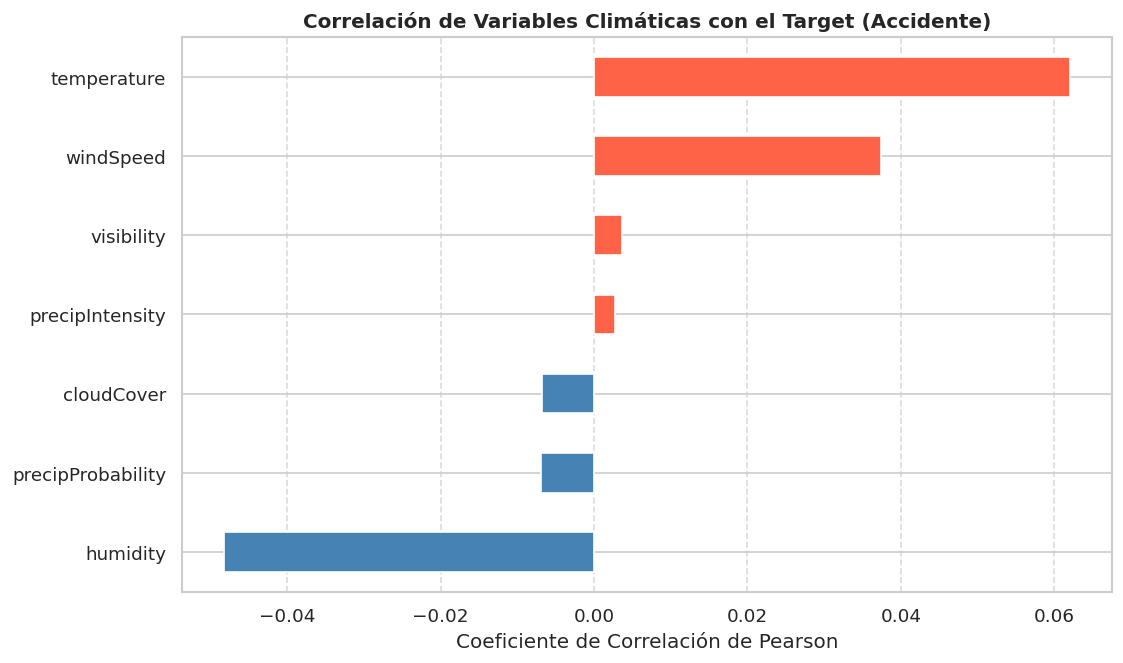

/tmp/ipykernel_4273/1202825560.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target', y='humidity', ax=axes[0], palette='Set2')
/tmp/ipykernel_4273/1202825560.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Sin Accidente', 'Con Accidente'])
/tmp/ipykernel_4273/1202825560.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target', y='precipIntensity', ax=axes[1], palette='Set2')
/tmp/ipykernel_4273/1202825560.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  a

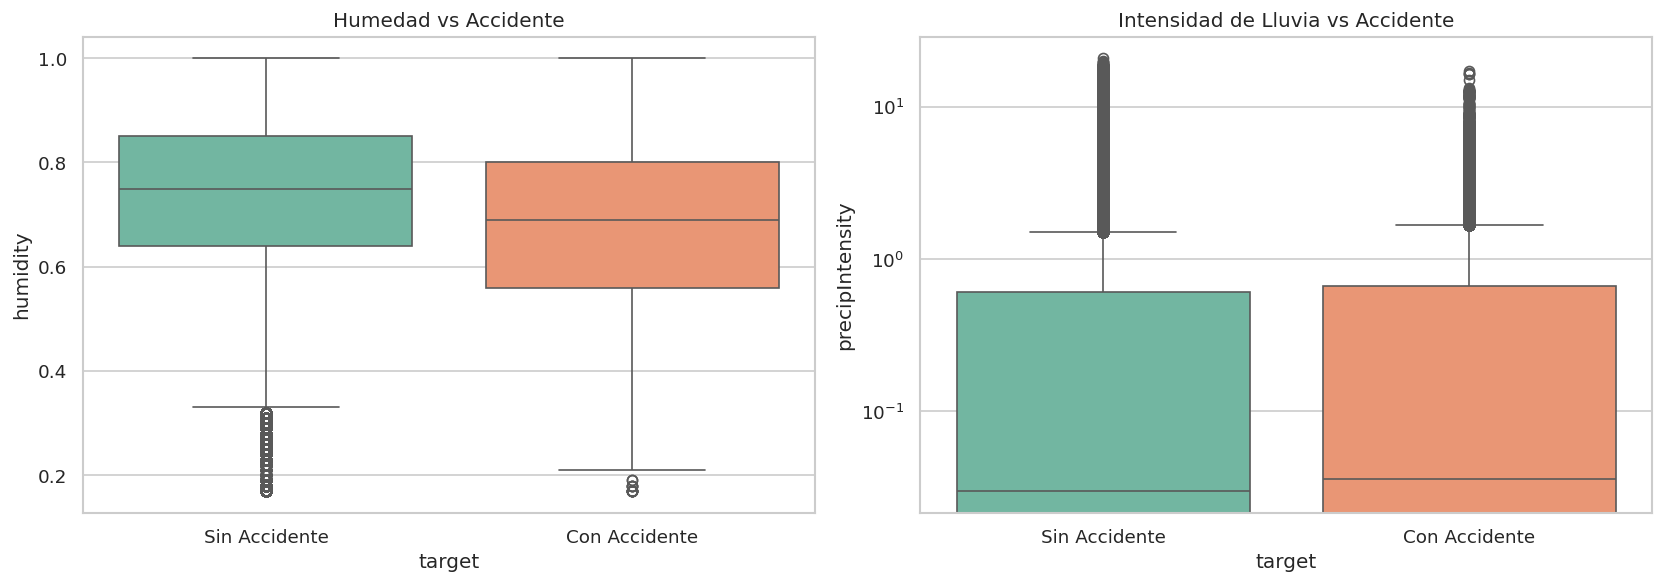

Promedio de variables climáticas según presencia de accidente:


,temperature,humidity,precipIntensity,precipProbability,windSpeed,visibility,cloudCover
target,,,,,,,
0,19.624997,0.735288,0.475840,0.159777,1.576782,11.316265,0.722608
1,21.535629,0.673776,0.495942,0.147410,1.963154,11.417221,0.711025


In [16]:
# ==========================================
# 4. EDA: ANÁLISIS CLIMÁTICO
# ==========================================

# 4.1 Selección de variables climáticas
vars_clima = ['temperature', 'humidity', 'precipIntensity', 'precipProbability', 
              'windSpeed', 'visibility', 'cloudCover', 'pressure']

# Asegurar que solo usamos las que están en el DF
vars_clima = [v for v in vars_clima if v in df.columns]

# --- Gráfico de Correlación ---
plt.figure(figsize=(10, 6))
correlaciones = df[vars_clima + ['target']].corr()['target'].drop('target').sort_values()
colores = ['tomato' if c > 0 else 'steelblue' for c in correlaciones]

correlaciones.plot(kind='barh', color=colores, edgecolor='white')
plt.title('Correlación de Variables Climáticas con el Target (Accidente)', fontweight='bold')
plt.xlabel('Coeficiente de Correlación de Pearson')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# --- Análisis de Distribución (Boxplots) ---
# Vamos a ver cómo cambia la humedad y la lluvia ante un accidente
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='target', y='humidity', ax=axes[0], palette='Set2')
axes[0].set_title('Humedad vs Accidente')
axes[0].set_xticklabels(['Sin Accidente', 'Con Accidente'])

sns.boxplot(data=df, x='target', y='precipIntensity', ax=axes[1], palette='Set2')
axes[1].set_title('Intensidad de Lluvia vs Accidente')
axes[1].set_xticklabels(['Sin Accidente', 'Con Accidente'])
axes[1].set_yscale('log') # Escala logarítmica para ver mejor la lluvia

plt.tight_layout()
plt.show()

# Resumen Estadístico
print("Promedio de variables climáticas según presencia de accidente:")
display(df.groupby('target')[vars_clima].mean())